In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder


In [2]:
df = pd.read_csv('Data\Housing.csv')

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.describe(include='object')

C:\Users\Mwangi Maina\AppData\Local\Temp\ipykernel_13008\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [5]:
df['area'].describe()

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df_2 = df[['area', 'price']]

In [8]:
df_2.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [9]:
df.info

<bound method DataFrame.info of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no

In [10]:
rows, columns = df.shape
output = f'The Housing dataset has {rows} records and {columns} features.'
output

'The Housing dataset has 545 records and 13 features.'

***Univariate Analysis***

In [11]:
#list(df.columns)
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

***Bivariate Analysis***

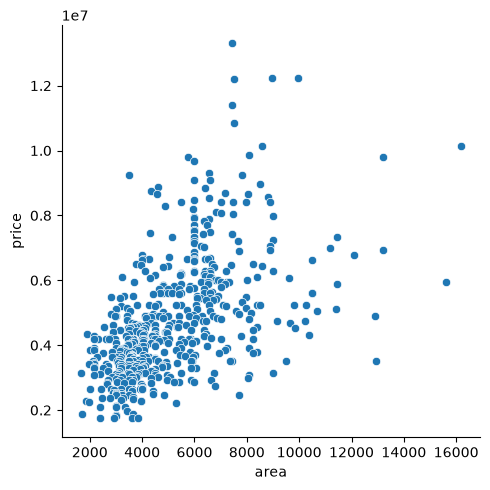

In [12]:
sns.relplot(data=df, x='area', y='price')

In [13]:
x = pd.DataFrame(df_2['area'])
y = pd.DataFrame(df_2['price'])

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=30, random_state=42)

In [15]:
linear_reg_model = LinearRegression()

In [16]:
linear_reg_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[438.46]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2516004.13]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [17]:
y_predicted = linear_reg_model.predict(x_test)

In [18]:
y_predicted

array([[5102942.48517905],
       [5366020.96229634],
       [4287399.20611546],
       [4708324.76950312],
       [4252322.07583316],
       [5462483.07057267],
       [6251718.50192453],
       [4703940.12821783],
       [3936627.90329241],
       [3699857.27388686],
       [6278026.34963626],
       [4240922.00849141],
       [4147090.68498624],
       [3875242.92529838],
       [4256706.71711844],
       [4107628.91341865],
       [3392932.38391669],
       [5146788.89803193],
       [5081019.27875261],
       [5146788.89803193],
       [4717094.0520737 ],
       [5508521.8040682 ],
       [4115959.7318607 ],
       [4182167.81526855],
       [6133333.18722175],
       [6883106.84700602],
       [3870858.28401309],
       [3831396.5124455 ],
       [8303730.62343936],
       [3831396.5124455 ]])

In [19]:
user_area_input = int(input('Enter the area of the house in square feet(Enter numbers only): '))
y_hat = linear_reg_model.predict([[user_area_input]])
y_hat

c:\Users\Mwangi Maina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[7928843.79354723]])

In [20]:
x_test

,area
316,5900
77,6500
360,4040
90,5000
493,3960
209,6720
176,8520
249,4990
516,3240
426,2700


In [21]:
y_test

,price
316,4060000
77,6650000
360,3710000
90,6440000
493,2800000
209,4900000
176,5250000
249,4543000
516,2450000
426,3353000


In [22]:
r2_score(y_test, y_predicted)

0.46590120608285224

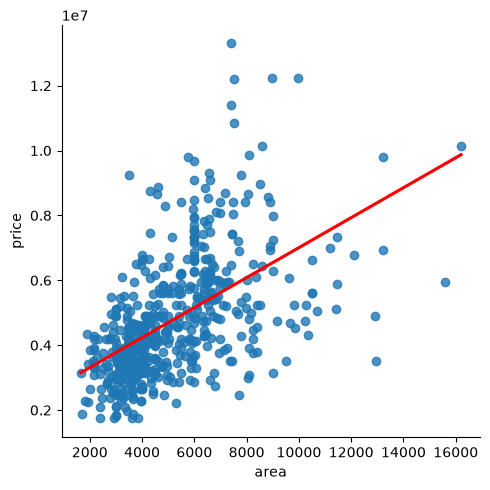

In [23]:
sns.lmplot(data=df, x='area', y='price', ci=None, line_kws={'color':'red'})

***Encoding (Binary & One hot encoding)***

Binary Encoding

In [24]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [25]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [26]:
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

In [27]:
for col in binary_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [28]:
one_hot = pd.get_dummies(df['furnishingstatus'], dtype=int)
one_hot.head(5)

,furnished,semi-furnished,unfurnished
0,1,0,0
1,1,0,0
2,0,1,0
3,1,0,0
4,1,0,0


In [29]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(df[['furnishingstatus']])
encoder.categories_
encoded_furnishingstatus = encoder.transform(df[['furnishingstatus']]).toarray()

encoded_df = pd.DataFrame(
    encoded_furnishingstatus,
    columns=encoder.get_feature_names_out(['furnishingstatus'])
    )

In [30]:
encoded_df.head(5)

,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [31]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


**concatenation of both dataframes (original and encoded df)**


In [32]:
# reset the index or first df
df_2 = df.reset_index(drop=True)

# reset index of the encoded df
encoded_df = encoded_df.reset_index(drop=True)

# combine the two df's
df_3 = pd.concat([df_2.drop(columns=['furnishingstatus']), encoded_df], axis=1)

In [33]:
df_3.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.0,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0,0.0,0.0


***Multivariate analysis***

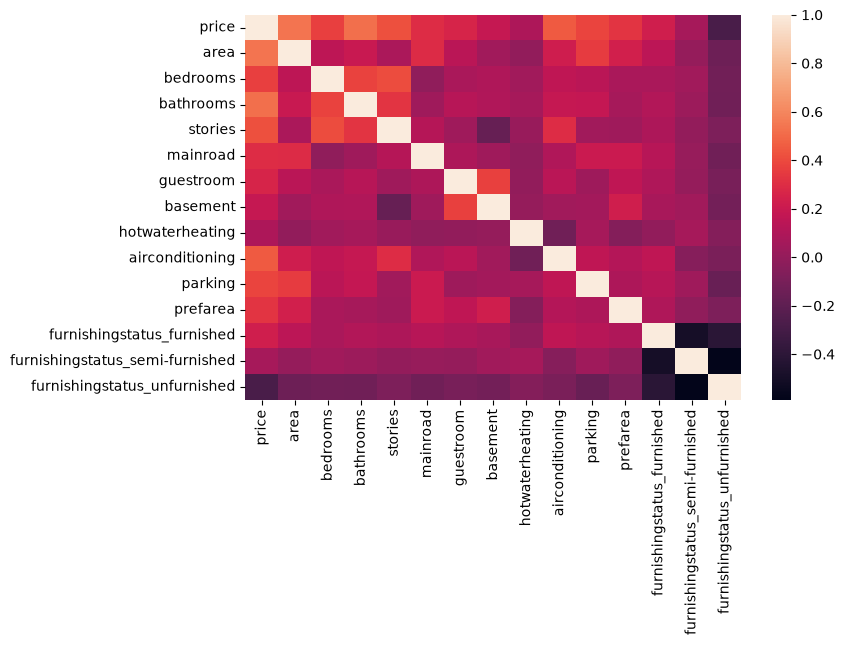

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))#adjusting the size of the figure

#actually plotting the heatmap
sns.heatmap(df_3.corr())
plt.show()

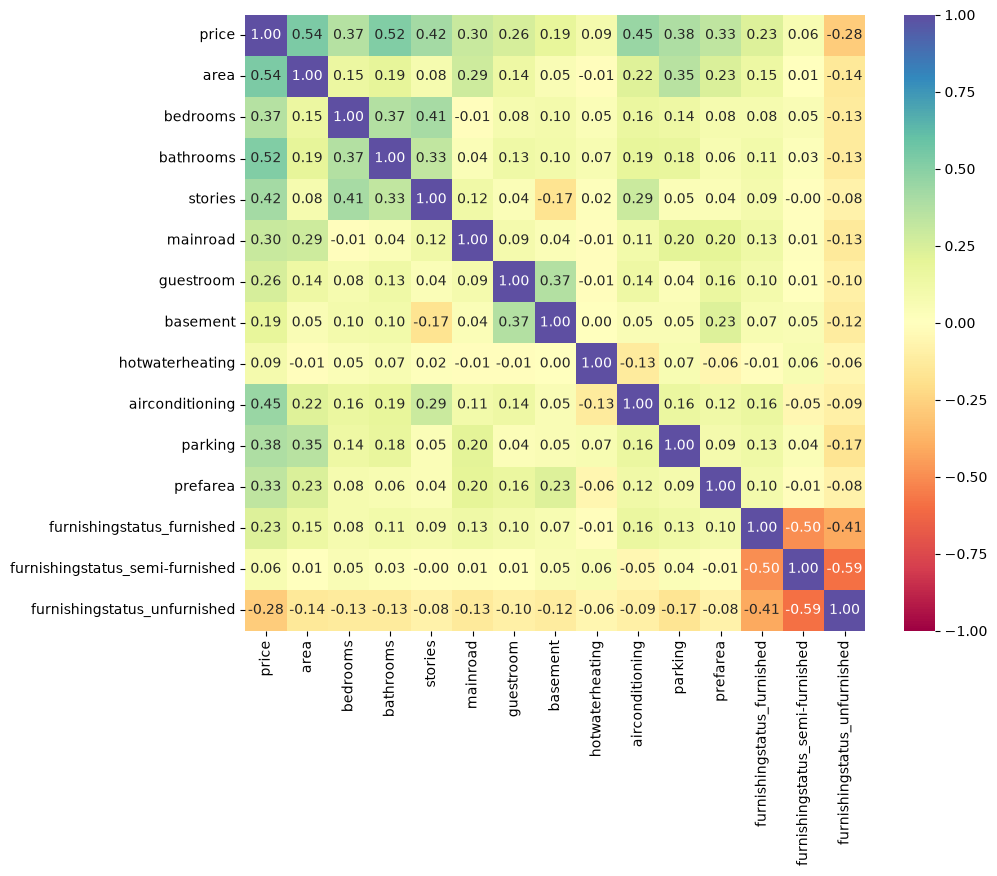

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_3.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

***Multi-Linear Regression***

In [36]:
columns = df_3.columns
columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_furnished',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')

*Extracting the target and independent variables*

In [37]:
y_multilinear = df_3['price']
#x_multilinear = df_3.columns[1:]
#x_multilinear

In [38]:
y_multilinear

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [39]:
x_multilinear = df_3.drop(columns=['price'])
x_multilinear

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,1.0,0.0,0.0
1,8960,4,4,4,1,0,0,0,1,3,0,1.0,0.0,0.0
2,9960,3,2,2,1,0,1,0,0,2,1,0.0,1.0,0.0
3,7500,4,2,2,1,0,1,0,1,3,1,1.0,0.0,0.0
4,7420,4,1,2,1,1,1,0,1,2,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0.0,0.0,1.0
541,2400,3,1,1,0,0,0,0,0,0,0,0.0,1.0,0.0
542,3620,2,1,1,1,0,0,0,0,0,0,0.0,0.0,1.0
543,2910,3,1,1,0,0,0,0,0,0,0,1.0,0.0,0.0


*Spliting the Data*

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x_multilinear, y_multilinear, test_size=30, random_state=42)

In [41]:
x_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
70,4000,3,2,2,1,0,1,0,1,0,1,0.0,1.0,0.0
398,3120,3,1,2,1,0,0,0,0,1,0,0.0,0.0,1.0
79,6000,3,2,3,1,1,0,0,1,0,0,1.0,0.0,0.0
483,6615,3,1,2,1,0,0,0,0,0,0,0.0,1.0,0.0
429,4775,4,1,2,1,0,0,0,0,0,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,0.0,0.0,1.0
106,5450,4,2,1,1,0,1,0,1,0,1,0.0,1.0,0.0
270,4500,3,2,3,1,0,0,1,0,1,0,1.0,0.0,0.0
435,4040,2,1,1,1,0,0,0,0,0,0,0.0,0.0,1.0


In [42]:
y_train

70     6790000
398    3500000
79     6650000
483    2940000
429    3325000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 515, dtype: int64

*get instance of the linear regression model*

In [43]:
multilinear_reg_model = LinearRegression()
multilinear_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


*Fit the model*

In [44]:
multilinear_reg_model.fit(x_train, y_train)
multilinear_reg_model #trained model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 228.93, 121271.72,1033142.25,..., 174248.48, 80829.05,-255077.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['area','bedrooms','bathrooms',...,'furnishingstatus_furnished', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6.022e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


*# 1. *Create dummy dataset with exactly 2 features*

In [45]:
np.random.seed(42)
X = np.random.rand(100, 2) * 10  # Features: X1, X2
y = 2 * X[:, 0] + 3 * X[:, 1] + np.random.randn(100) * 2  # Target

In [46]:
sns.lmplot(data=df_3.head(10), x='X1', y='y', ci=None, line_kws={'color':'red'})

KeyError: "None of [Index(['X1', 'y'], dtype='str')] are in the [columns]"